In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\rampa\DS Python Class\Baking Loan\Data\Cleande data\banking_loan_cleand_data.csv")

In [3]:
#Convert Application Date

#When data is imported from a CSV file, the Application_Date column may not be recognized as a date datatype.
#Therefore, it is converted to the datetime datatype before performing date-based analysis such as extracting the application year.

df["application_date"] = pd.to_datetime(df["application_date"])
df["application_Year"] = df["application_date"].dt.year

### 1. Loan Applications by Year

**Business Question:**
How does the number of loan applications change over different years?

**Why are we analyzing this?**
To identify yearly trends in loan demand and understand whether the number of applications is increasing, decreasing, or remaining stable.


### EDA Insight

> **Loan applications remained stable in 2024–2025 but declined significantly in 2026, indicating lower customer demand or application activity.**

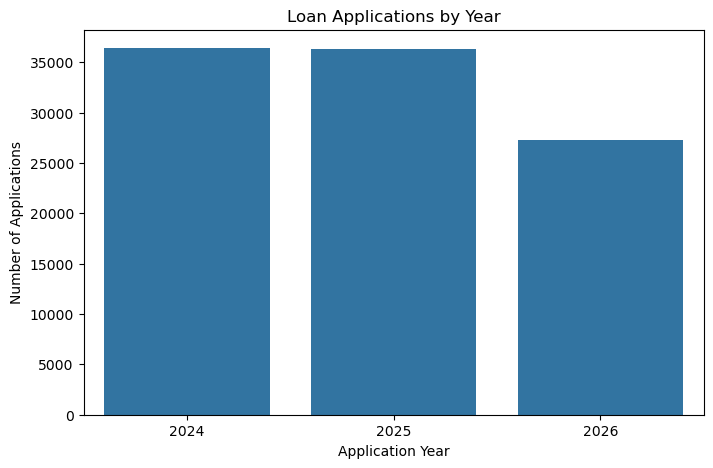

In [4]:
application_year = df["application_Year"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=application_year.index,
    y=application_year.values
)

plt.title("Loan Applications by Year")
plt.xlabel("Application Year")
plt.ylabel("Number of Applications")

plt.show()

### 2. Loan Applications by Loan Type

**Business Question:**
Which loan types are most popular among customers?

**Why are we analyzing this?**
To understand customer preferences and identify the loan products with the highest demand.

---

### EDA Insight

> **Personal Loan has the highest share of applications (30.1%), followed by Home Loan (29.9%), while Education Loan has the lowest share (10.0%).**

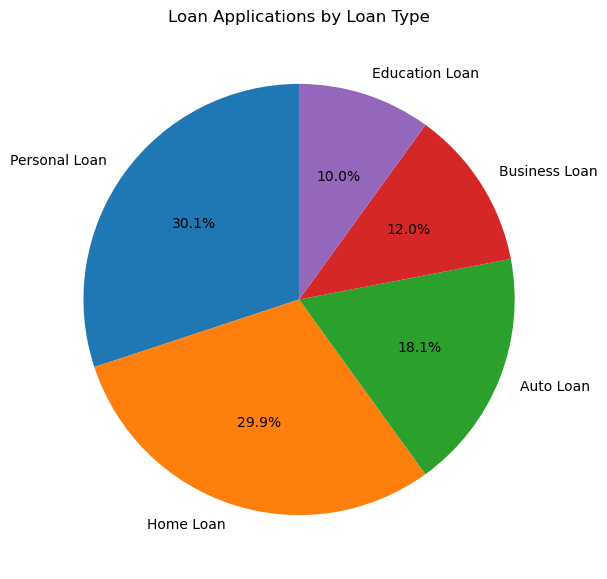

In [5]:
loan_type_count = df["loan_type"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    loan_type_count.values,
    labels=loan_type_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Loan Applications by Loan Type")

plt.show()

### 3. Approved vs Rejected

**Business Question:**
What is the distribution of approved and rejected loan applications?

**Why are we analyzing this?**
To understand the overall loan approval pattern and determine how many applications successfully pass the approval process.

---

### EDA Insight

> **Approved loan applications are significantly higher than rejected applications, indicating a relatively strong approval rate.**

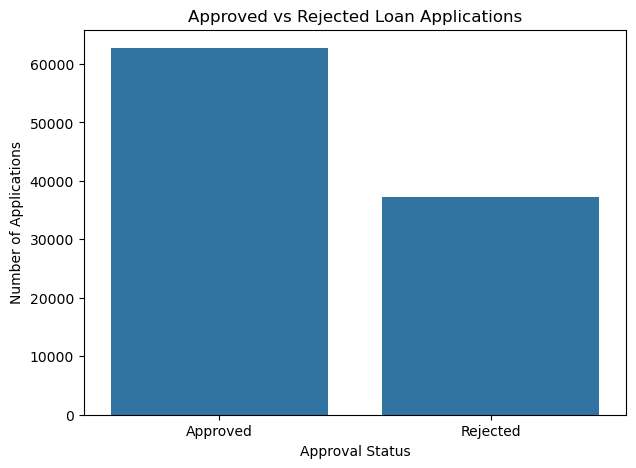

In [6]:
approval_count = df["approval_status"].value_counts()

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="approval_status"
)

plt.title("Approved vs Rejected Loan Applications")
plt.xlabel("Approval Status")
plt.ylabel("Number of Applications")

plt.show()

### 4. Loan Amount Distribution

**Business Question:**
What is the distribution of loan amounts requested by customers?

**Why are we analyzing this?**
To understand the typical loan amounts requested by customers and identify unusually small or large loan applications.

### EDA Insight

> **Most loan amounts are concentrated below ₹15 lakhs, while higher-value loans occur less frequently.**

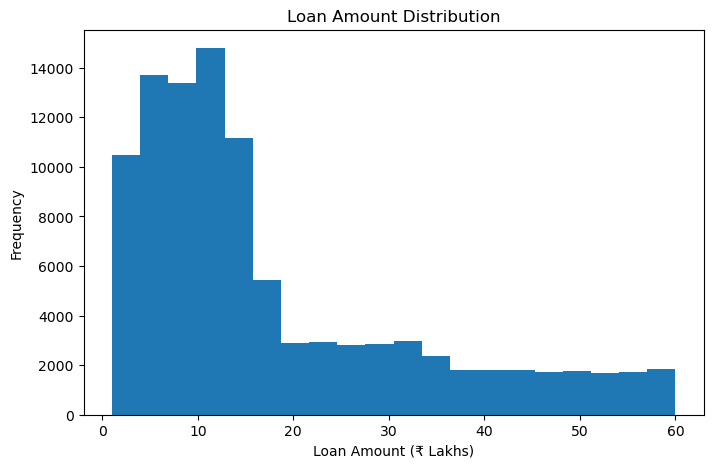

In [7]:
loan_amount_lakh = df["loan_amount"] / 100000

plt.figure(figsize=(8, 5))

plt.hist(loan_amount_lakh, bins=20)

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount (₹ Lakhs)")
plt.ylabel("Frequency")

plt.show()

### 5. Credit Score Distribution

**Business Question:**
How are customers distributed across different credit score ranges?

**Why are we analyzing this?**
To understand the overall creditworthiness of loan applicants and identify the common credit score ranges.

---

### EDA Insight

> **Credit scores are mainly concentrated around 650–740, with a median of approximately 695, indicating a generally moderate-to-good credit profile.**

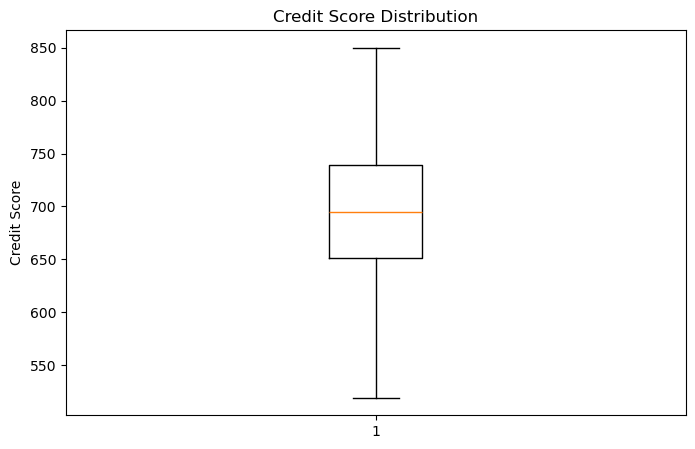

In [8]:
plt.figure(figsize=(8, 5))

plt.boxplot(df["credit_score"])

plt.title("Credit Score Distribution")
plt.ylabel("Credit Score")

plt.show()

### 6. Loan Status Distribution

**Business Question:**
What is the distribution of different loan statuses?

**Why are we analyzing this?**
To understand the current status of loans and identify patterns such as active, completed, or defaulted loans.

---

### EDA Insight

> **Active and rejected loans make up the largest share of loan statuses, while default and overdue loans are comparatively low.**

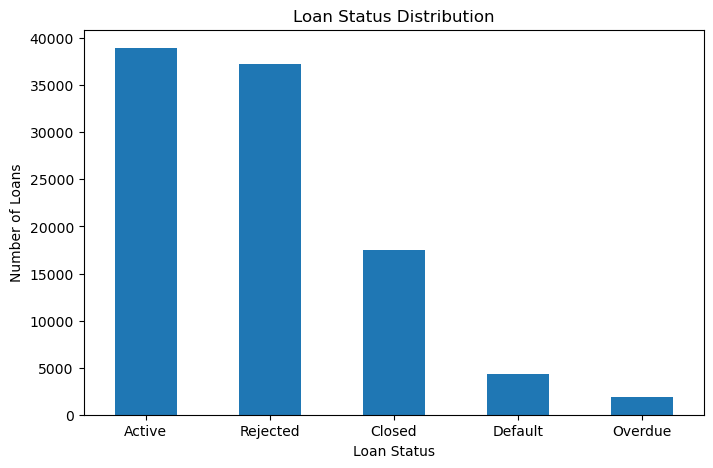

In [9]:


df["loan_status"].value_counts().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")
plt.xticks(rotation=0)
plt.show()

### 7. Payment Delay Distribution

**Business Question:**
How are customers distributed based on their payment delay days?

**Why are we analyzing this?**
To understand customer repayment behavior and identify the level of payment delays among customers.

---

### EDA Insight

> **Most payments have little to no delay, while a small number of loans show significantly higher payment delays.**

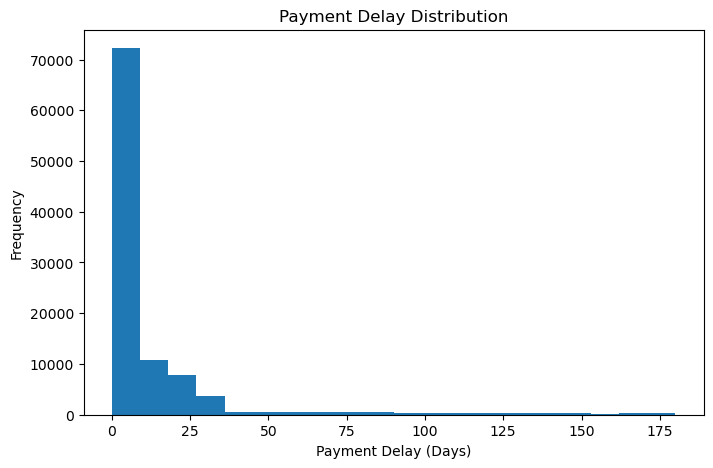

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(df["payment_delay_days"], bins=20)

plt.title("Payment Delay Distribution")
plt.xlabel("Payment Delay (Days)")
plt.ylabel("Frequency")

plt.show()

### 8. Average Loan Amount by Employment Type

**Business Question:**
Does the average loan amount differ across different employment types?

**Why are we analyzing this?**
To understand borrowing patterns across employment groups and identify whether certain employment types request higher average loan amounts.

---

### EDA Insight

> **Average loan amounts are nearly similar across all employment types, showing little variation in borrowing levels.**
> 

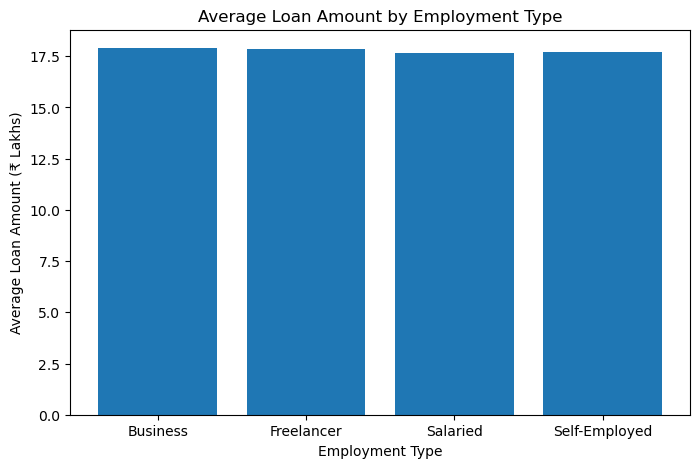

In [11]:
avg_loan = df.groupby("employment_type")["loan_amount"].mean() / 100000

plt.figure(figsize=(8, 5))

plt.bar(avg_loan.index, avg_loan.values)

plt.title("Average Loan Amount by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Average Loan Amount (₹ Lakhs)")

plt.show()

### 9. Credit Score vs Loan Amount

**Business Question:**
Is there a relationship between credit score and loan amount?

**Why are we analyzing this?**
To understand whether customers with higher credit scores tend to request different loan amounts and identify any relationship between creditworthiness and borrowing behavior.


### EDA Insight

> **Loan amounts are widely distributed across credit scores, showing no strong relationship between credit score and loan amount.**

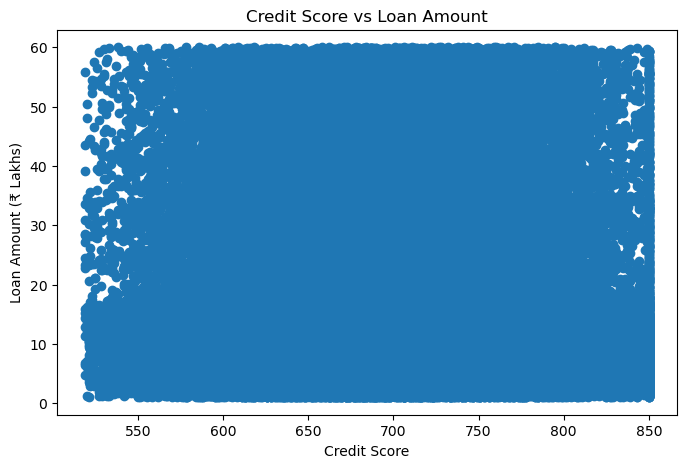

In [12]:
plt.figure(figsize=(8, 5))

plt.scatter(df["credit_score"], df["loan_amount"] / 100000)

plt.title("Credit Score vs Loan Amount")
plt.xlabel("Credit Score")
plt.ylabel("Loan Amount (₹ Lakhs)")

plt.show()

### MySQL Connection

> **Connected the cleaned banking loan dataset to MySQL using SQLAlchemy and PyMySQL for SQL-based analysis.**

In [13]:
from sqlalchemy import create_engine

username = "root"
password = "12345"
host = "localhost"
database = "Banking_loan_db"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:3306/{database}"
)

# Test MySQL connection
with engine.connect() as connection:
    print("MySQL connected successfully!")

MySQL connected successfully!


### Uploading Data to MySQL

> **Uploaded the cleaned banking loan dataset into MySQL for SQL-based analysis.**

In [14]:
df.to_sql(
    "loan_applications",
    con=engine,
    if_exists="replace",
    index=False
)

print("loan_applications uploaded successfully!")

loan_applications uploaded successfully!
